In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import itertools


def _node_positions(radius=4.0, number_radius_ratio=0.82):
    positions = {}
    r_inner = radius * number_radius_ratio
    for n in range(1, 9):
        angle_deg = -90 + (n - 1) * 45  
        angle_rad = np.deg2rad(angle_deg)
        x = r_inner * np.cos(angle_rad)
        y = r_inner * np.sin(angle_rad)
        positions[n] = (x, y)
    positions[9] = (0.0, 0.0)
    return positions


def draw_figure(arrows=(), colors=None,
                radius=4.0, square_size=0.62,
                curve_strength=0.25):
    for idx, (s, e) in enumerate(arrows):
        if s not in range(0, 10) or e not in range(0, 10) :
            raise ValueError(f"{s} and {e} must be an integer between 0 and 9")

    positions = _node_positions(radius=radius)

    fig, ax = plt.subplots(figsize=(8,8), dpi=100)
    ax.set_aspect("equal")
    ax.axis("off")

    outer_circle = mpatches.Circle((0, 0), radius, fill=False,
                                    linewidth=2.5, edgecolor="black", zorder=1)
    ax.add_patch(outer_circle)

    for n, (x, y) in positions.items():
        sq = mpatches.Rectangle((x - square_size / 2, y - square_size / 2),
                                 square_size, square_size,
                                 fill=True, facecolor="white",
                                 edgecolor="black", linewidth=1.6, zorder=3)
        ax.add_patch(sq)
        ax.text(x, y, str(n), ha="center", va="center",
                 fontsize=18, fontweight="bold", zorder=4)

    def add_arrow(start_n, end_n, color, rad_sign=1.0):
        x0, y0 = positions[start_n]
        x1, y1 = positions[end_n]
        rad = curve_strength * rad_sign
        arrow = FancyArrowPatch((x0, y0), (x1, y1),
                                 connectionstyle=f"arc3,rad={rad}",
                                 arrowstyle="-|>", mutation_scale=22,
                                 linewidth=2.4, color=color,
                                 shrinkA=18, shrinkB=18, zorder=5)
        ax.add_patch(arrow)

    default_cycle = ["red", "blue", "green", "orange", "purple",
                      "brown", "magenta", "teal", "black", "gold"]
    if colors is None:
        color_list = list(itertools.islice(itertools.cycle(default_cycle), len(arrows)))
    elif isinstance(colors, str):
        color_list = [colors] * len(arrows)
    else:
        colors = list(colors)
        if len(colors) != len(arrows):
            raise ValueError(f"colors has {len(colors)} entries but there are {len(arrows)} arrows")
        color_list = colors


    for idx, (s, e) in enumerate(arrows):
        add_arrow(s, e, color_list[idx])

    pad = radius * 0.1
    ax.set_xlim(-radius - pad, radius + pad)
    ax.set_ylim(-radius - pad, radius + pad)

    fig.tight_layout()

    plt.show()
    return fig, ax

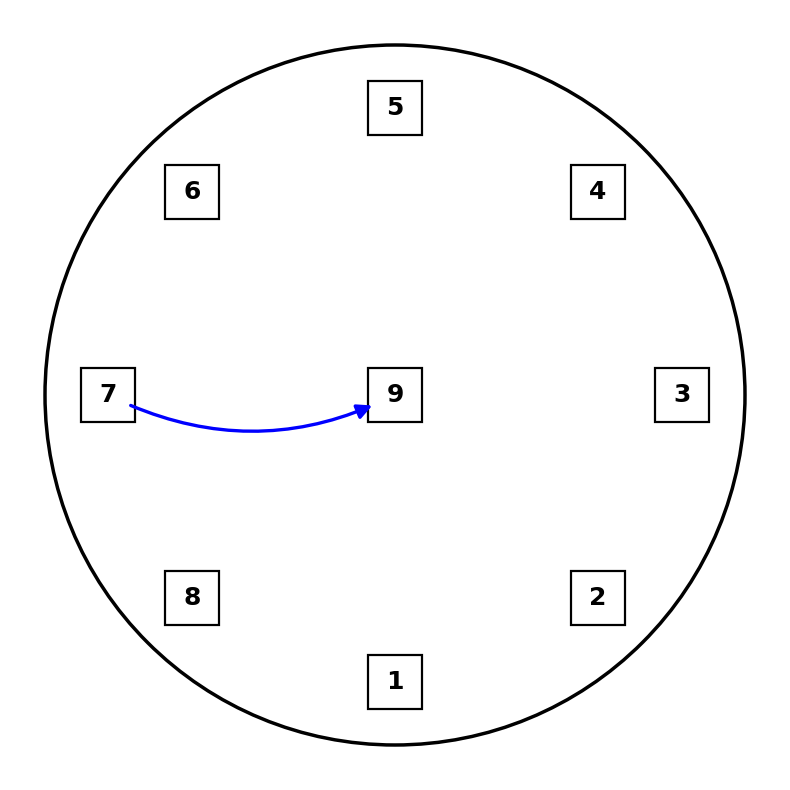

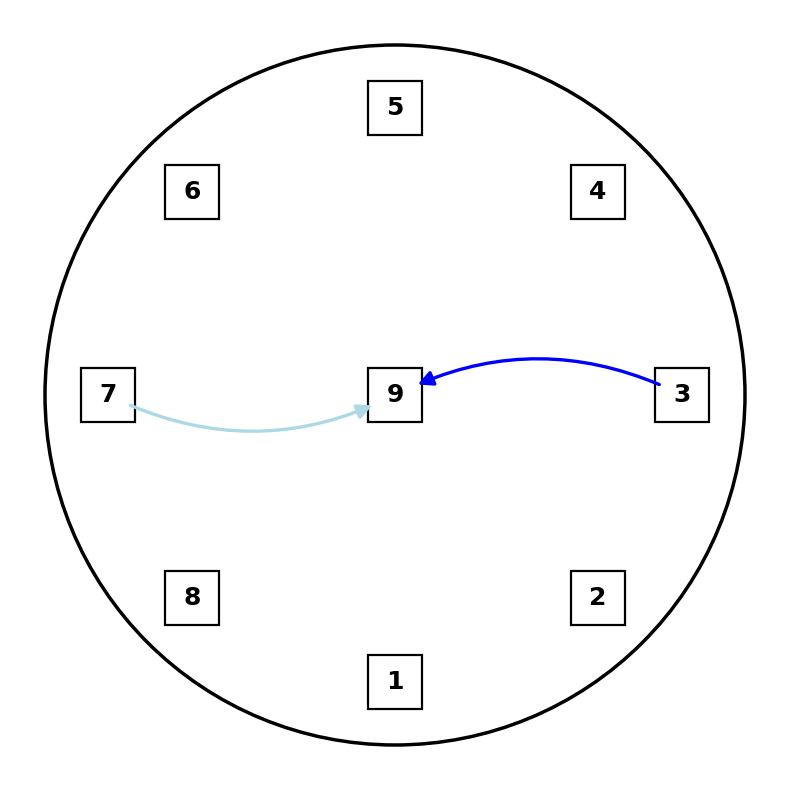

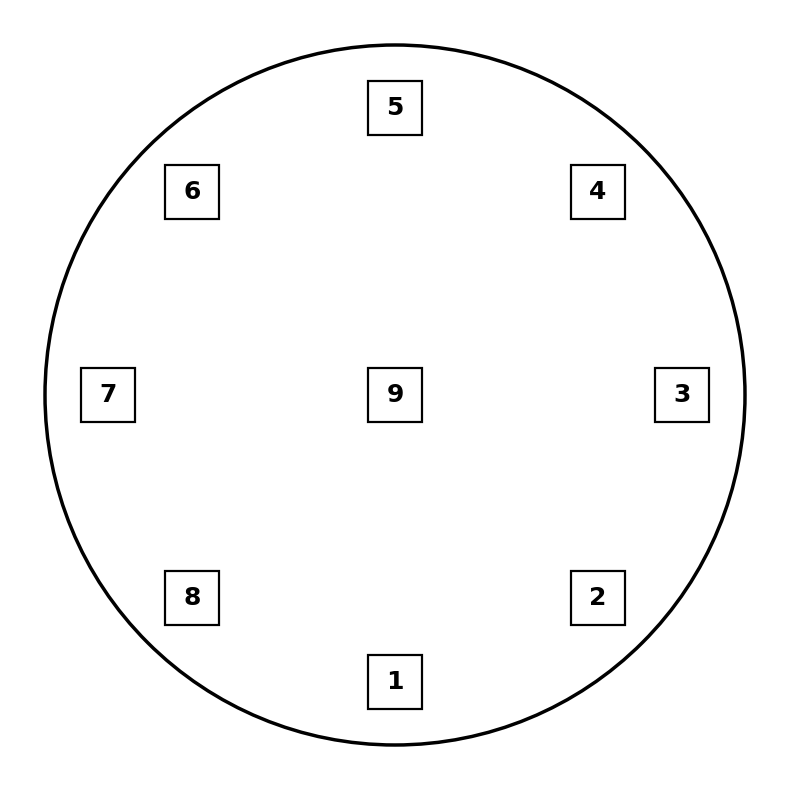

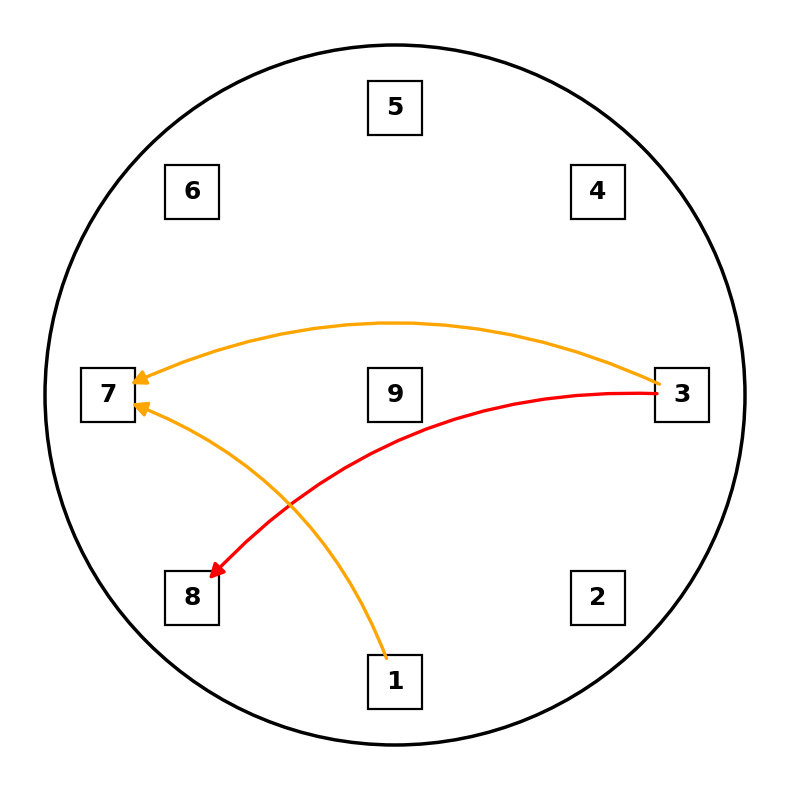

(<Figure size 800x800 with 1 Axes>, <AxesSubplot: >)

In [2]:
draw_figure([(7,9)], ['blue'])
draw_figure([(7,9), (3,9)], ['lightblue', 'blue'])
draw_figure()
draw_figure([(3,8), (3,7), (1,7)], ['red', 'orange', 'orange'])

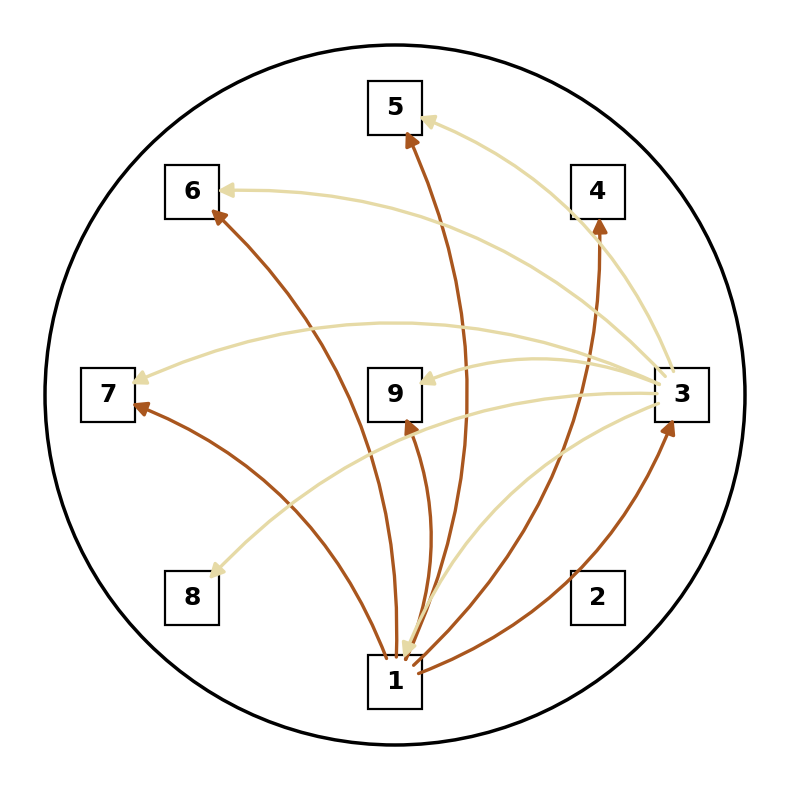

(<Figure size 800x800 with 1 Axes>, <AxesSubplot: >)

In [77]:
s1= [(1,3), (1,4), (1,5), (1,6), (1,7), (1,9)]
s3= [(3,1), (3,5), (3,9), (3,6), (3,7), (3,8)]
colors= ['#A9561E']*len(s1) + ['#E6DAA6']*len(s3)
draw_figure(s1+s3, colors)

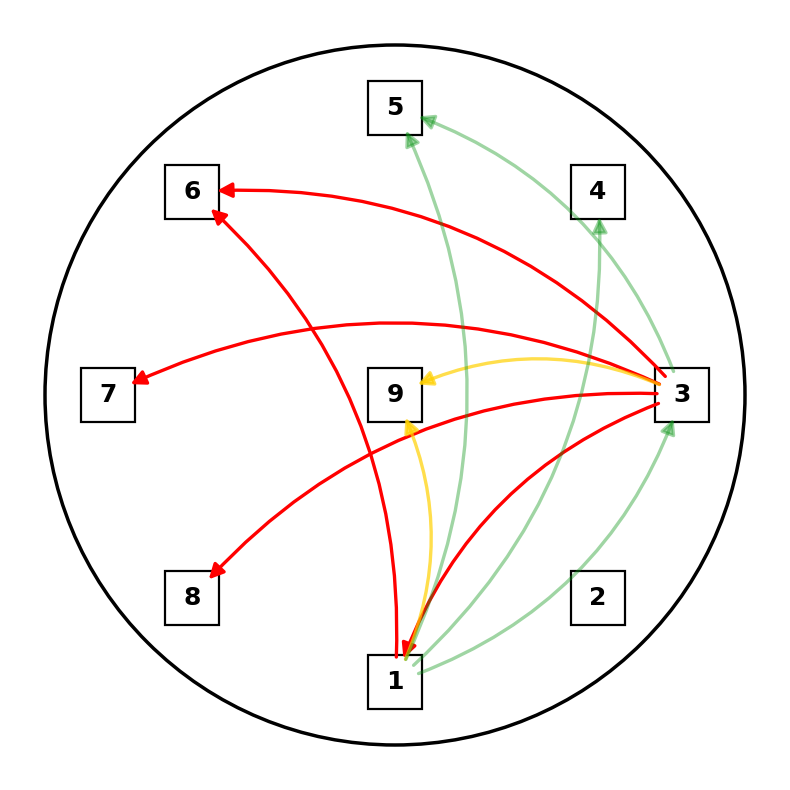

(<Figure size 800x800 with 1 Axes>, <AxesSubplot: >)

In [93]:
from matplotlib.colors import to_rgba
fails = [(3,1), (3,7), (3,8), (1,6), (3,6)]
close = [(1,9), (3,9)]
good = [(1,3), (1,4), (1,5), (3,5)]
fc = ["red"]*len(fails)
cc= [to_rgba("#FFD000", 0.7)]*len(close)
gc=[to_rgba("#0F961A", 0.4)]*len(good)
draw_figure(fails+close+good, fc+cc+gc)